# Notebook 05: Exposure at Default (EAD) Model

## Prior Role Connection
At my prior institution, EAD was assumed to be 1.0× the outstanding balance for
fully-drawn term products (mortgages, auto loans). This is the standard simplifying
assumption under Basel II/III for on-balance-sheet exposures where there is no undrawn
commitment. LendingClub personal loans are fully disbursed at origination — the borrower
receives the full funded amount upfront with no revolving component or further draw-down
facility. This means the Credit Conversion Factor (CCF) for undrawn commitments is
irrelevant; instead, EAD equals the remaining amortized balance at time of default.

## Why EAD = 1 Works for Fully-Drawn Term Loans
For revolving credit (credit cards, HELOCs), borrowers can increase utilization before
default, making EAD > current balance. The CCF captures this additional draw-down risk.
For term loans:
- **No undrawn commitment**: The full loan is disbursed at origination
- **CCF (undrawn) = N/A**: There is no unfunded portion to convert
- **EAD = scheduled remaining balance**: Purely a function of the amortization schedule
- **Simplification**: EAD/funded_amnt decreases predictably with payments made

In practice, we model the **remaining principal at default** which is a function of
when the borrower stopped paying (time-to-default) and the loan's amortization schedule.

## Objective
1. Reconstruct EAD from the amortization schedule (since `out_prncp` is zeroed
   after charge-off in the data snapshot)
2. Compute CCF = EAD / funded_amnt for the defaulted portfolio
3. Build a Random Forest regressor to predict EAD from origination features
4. Compare RF predictions to the analytical amortization formula
5. Validate: MAPE < 15%, portfolio average CCF consistent with expectations

**Target:** MAPE < 15%

## Step 1: Setup — Imports and Configuration

In [1]:
import sys
import json
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import LabelEncoder

# Project imports
sys.path.insert(0, str(Path('..').resolve()))
from config import (
    DATA_PROCESSED_PATH, DATA_RESULTS_PATH, DATA_MODELS_PATH,
    TARGET_COL, RANDOM_STATE, GRADE_ORDER,
)
from src.models import compute_ead_amortization, compute_ccf, fit_ead_model

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"Random state: {RANDOM_STATE}")
print("Setup complete.")

Random state: 42
Setup complete.


## Step 2: Load Data and Filter to Defaulted Loans

EAD is modeled on **defaulted loans only** — we need to know the exposure at the
time of default, which is only observable for loans that actually defaulted.

In [2]:
# Load original (non-WOE) parquet files
train = pd.read_parquet(DATA_PROCESSED_PATH / "train.parquet")
val   = pd.read_parquet(DATA_PROCESSED_PATH / "val.parquet")
test  = pd.read_parquet(DATA_PROCESSED_PATH / "test.parquet")

print(f"Full datasets:")
print(f"  Train: {train.shape[0]:,} rows  |  Default rate: {train[TARGET_COL].mean():.4f}")
print(f"  Val:   {val.shape[0]:,} rows  |  Default rate: {val[TARGET_COL].mean():.4f}")
print(f"  Test:  {test.shape[0]:,} rows  |  Default rate: {test[TARGET_COL].mean():.4f}")

# Filter to defaulted loans
train_def = train[train[TARGET_COL] == 1].copy()
val_def   = val[val[TARGET_COL] == 1].copy()
test_def  = test[test[TARGET_COL] == 1].copy()

print(f"\nDefaulted loans:")
print(f"  Train: {len(train_def):,}")
print(f"  Val:   {len(val_def):,}")
print(f"  Test:  {len(test_def):,}")
print(f"  Total: {len(train_def) + len(val_def) + len(test_def):,}")

Full datasets:
  Train: 826,606 rows  |  Default rate: 0.1843
  Val:   293,105 rows  |  Default rate: 0.2329
  Test:  225,639 rows  |  Default rate: 0.2129



Defaulted loans:
  Train: 152,304
  Val:   68,252
  Test:  48,043
  Total: 268,599


## Step 3: Why `out_prncp` Cannot Be Used Directly

The LendingClub data snapshot records `out_prncp` as the **current** outstanding
principal. For charged-off loans, this is zeroed out after the write-off event —
the system moves the balance to a loss bucket. We must reconstruct the exposure
at the time of default using the amortization schedule.

In [3]:
# Demonstrate why out_prncp doesn't work for charged-off loans
print("=" * 70)
print("out_prncp DISTRIBUTION FOR DEFAULTED LOANS")
print("=" * 70)
print(f"  out_prncp == 0:   {(train_def['out_prncp'] == 0).sum():,} / {len(train_def):,} "
      f"({(train_def['out_prncp'] == 0).mean():.4%})")
print(f"  out_prncp > 0:    {(train_def['out_prncp'] > 0).sum():,}")
print(f"  Mean:             ${train_def['out_prncp'].mean():.2f}")
print()
print("→ out_prncp is zeroed after charge-off in this data snapshot.")
print("→ We reconstruct EAD from the amortization schedule.")

out_prncp DISTRIBUTION FOR DEFAULTED LOANS
  out_prncp == 0:   152,302 / 152,304 (99.9987%)
  out_prncp > 0:    2
  Mean:             $0.16

→ out_prncp is zeroed after charge-off in this data snapshot.
→ We reconstruct EAD from the amortization schedule.


## Step 4: Reconstruct EAD via Amortization Schedule

For a standard fixed-payment amortizing loan, the remaining principal after
`t` payments is:

$$B(t) = P \times \frac{(1+r)^n - (1+r)^t}{(1+r)^n - 1}$$

where:
- $P$ = funded amount (original principal)
- $r$ = monthly interest rate = annual rate / 12
- $n$ = total term in months (36 or 60)
- $t$ = months elapsed (from `issue_d` to `last_pymnt_d`)

In [4]:
def prepare_ead_data(df: pd.DataFrame) -> pd.DataFrame:
    """Reconstruct EAD and compute CCF for defaulted loans."""
    out = df.copy()

    # Compute months elapsed from origination to last payment
    out["months_elapsed"] = (
        (out["last_pymnt_d"] - out["issue_d"]).dt.days / 30.44
    ).round().clip(lower=0)

    # Reconstruct EAD via amortization formula
    out["ead"] = compute_ead_amortization(
        funded_amnt=out["funded_amnt"],
        int_rate=out["int_rate"],
        term=out["term"],
        months_elapsed=out["months_elapsed"],
    )

    # CCF = EAD / funded_amnt
    out["ccf"] = compute_ccf(out["ead"], out["funded_amnt"])

    # FICO average
    out["fico_avg"] = (out["fico_range_low"] + out["fico_range_high"]) / 2

    return out


train_def = prepare_ead_data(train_def)
val_def   = prepare_ead_data(val_def)
test_def  = prepare_ead_data(test_def)

# Drop rows where EAD could not be computed (missing last_pymnt_d, etc.)
for name, df in [("Train", train_def), ("Val", val_def), ("Test", test_def)]:
    n_before = len(df)
    n_valid = df["ead"].notna().sum()
    print(f"{name}: {n_valid:,} / {n_before:,} valid EAD values "
          f"({n_before - n_valid:,} dropped)")

train_def = train_def.dropna(subset=["ead"]).copy()
val_def   = val_def.dropna(subset=["ead"]).copy()
test_def  = test_def.dropna(subset=["ead"]).copy()

Train: 150,666 / 152,304 valid EAD values (1,638 dropped)
Val: 67,661 / 68,252 valid EAD values (591 dropped)
Test: 46,905 / 48,043 valid EAD values (1,138 dropped)


In [5]:
# EAD and CCF distribution summary
print("=" * 70)
print("RECONSTRUCTED EAD — PORTFOLIO SUMMARY (Train)")
print("=" * 70)
print(f"{'Metric':<25s} {'EAD ($)':>15s} {'CCF':>12s}")
print("-" * 55)
for stat, func in [("Mean", "mean"), ("Median", "median"),
                    ("Std", "std"), ("P5", lambda x: x.quantile(0.05)),
                    ("P25", lambda x: x.quantile(0.25)),
                    ("P75", lambda x: x.quantile(0.75)),
                    ("P95", lambda x: x.quantile(0.95))]:
    if isinstance(func, str):
        ead_val = getattr(train_def["ead"], func)()
        ccf_val = getattr(train_def["ccf"], func)()
    else:
        ead_val = func(train_def["ead"])
        ccf_val = func(train_def["ccf"])
    print(f"{stat:<25s} {ead_val:>15,.2f} {ccf_val:>12.4f}")

print()
print(f"Portfolio average CCF: {train_def['ccf'].mean():.4f}")
print(f"  Interpretation: On average, {train_def['ccf'].mean():.1%} of the original")
print(f"  funded amount remains outstanding at time of default.")
print(f"  This is expected for amortizing loans where defaults occur")
print(f"  across the loan lifecycle (median months to default: "
      f"{train_def['months_elapsed'].median():.0f}).")

RECONSTRUCTED EAD — PORTFOLIO SUMMARY (Train)
Metric                            EAD ($)          CCF
-------------------------------------------------------
Mean                            10,200.39       0.6384
Median                           8,802.71       0.6817
Std                              7,128.35       0.2307
P5                               1,338.51       0.1915
P25                              4,540.52       0.4858
P75                             14,309.72       0.8271
P95                             24,417.38       0.9378

Portfolio average CCF: 0.6384
  Interpretation: On average, 63.8% of the original
  funded amount remains outstanding at time of default.
  This is expected for amortizing loans where defaults occur
  across the loan lifecycle (median months to default: 17).


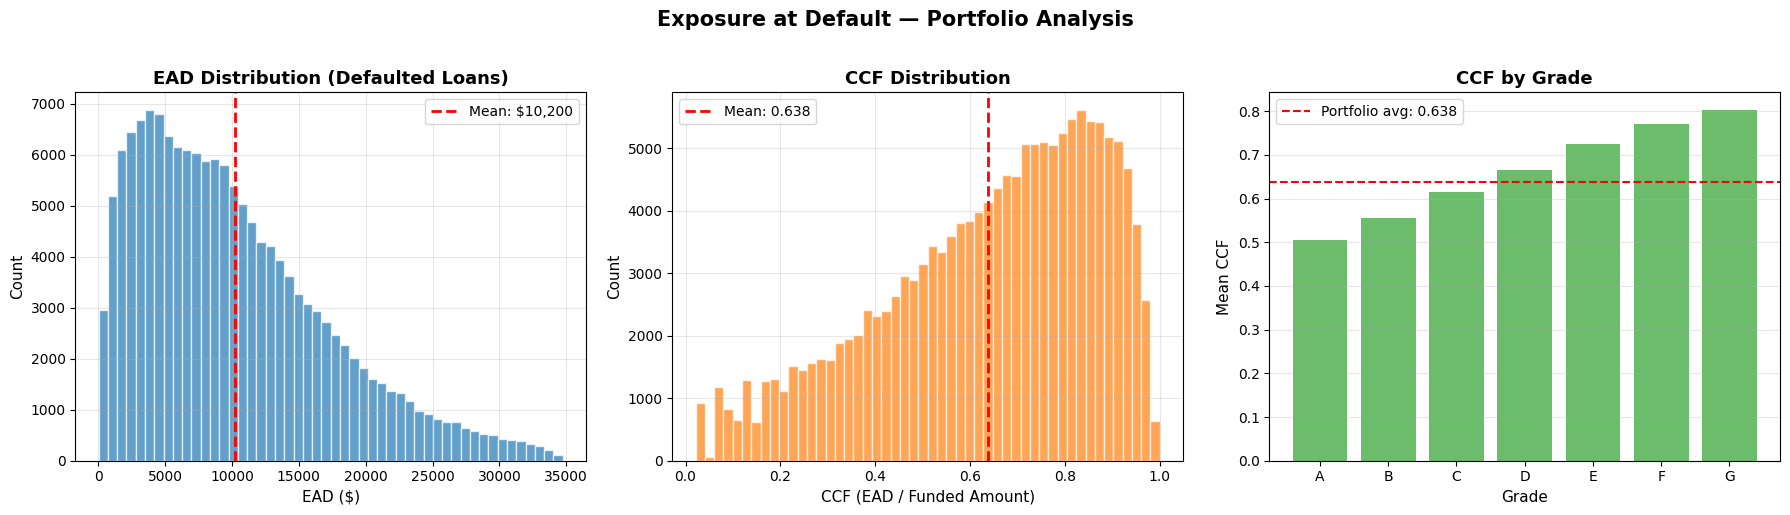

Saved: data/results/ead_distributions.png


In [6]:
# EAD and CCF distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: EAD distribution
ax = axes[0]
ax.hist(train_def["ead"], bins=50, color="#1f77b4", alpha=0.7, edgecolor="white")
ax.axvline(train_def["ead"].mean(), color="red", linestyle="--", linewidth=2,
           label=f"Mean: ${train_def['ead'].mean():,.0f}")
ax.set_xlabel("EAD ($)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("EAD Distribution (Defaulted Loans)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: CCF distribution
ax = axes[1]
ax.hist(train_def["ccf"], bins=50, color="#ff7f0e", alpha=0.7, edgecolor="white")
ax.axvline(train_def["ccf"].mean(), color="red", linestyle="--", linewidth=2,
           label=f"Mean: {train_def['ccf'].mean():.3f}")
ax.set_xlabel("CCF (EAD / Funded Amount)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("CCF Distribution", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: CCF by grade
ax = axes[2]
ccf_by_grade = train_def.groupby("grade")["ccf"].mean().reindex(GRADE_ORDER)
bars = ax.bar(ccf_by_grade.index, ccf_by_grade.values, color="#2ca02c", alpha=0.7)
ax.axhline(train_def["ccf"].mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Portfolio avg: {train_def['ccf'].mean():.3f}")
ax.set_xlabel("Grade", fontsize=11)
ax.set_ylabel("Mean CCF", fontsize=11)
ax.set_title("CCF by Grade", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Exposure at Default — Portfolio Analysis", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig(DATA_RESULTS_PATH / "ead_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/results/ead_distributions.png")

## Step 5: CCF by Segment Analysis

Examining how CCF varies by term, grade, and time-to-default. For amortizing
loans, CCF should be higher for:
- Shorter time-to-default (less principal paid down)
- 60-month terms (slower amortization)
- Higher-risk grades (tend to default earlier in the loan lifecycle)

In [7]:
print("=" * 70)
print("CCF BY SEGMENT")
print("=" * 70)

# By term
print("\nBy Term:")
for t in sorted(train_def["term"].unique()):
    subset = train_def[train_def["term"] == t]
    print(f"  {t:>2d} months: CCF = {subset['ccf'].mean():.4f}  "
          f"(n = {len(subset):,}, avg months to default = {subset['months_elapsed'].mean():.1f})")

# By grade
print("\nBy Grade:")
for g in GRADE_ORDER:
    subset = train_def[train_def["grade"] == g]
    if len(subset) > 0:
        print(f"  Grade {g}: CCF = {subset['ccf'].mean():.4f}  "
              f"(n = {len(subset):,}, avg months = {subset['months_elapsed'].mean():.1f})")

# By time-to-default quartile
print("\nBy Time-to-Default Quartile:")
train_def["ttd_q"] = pd.qcut(train_def["months_elapsed"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
for q in ["Q1", "Q2", "Q3", "Q4"]:
    subset = train_def[train_def["ttd_q"] == q]
    print(f"  {q}: CCF = {subset['ccf'].mean():.4f}  "
          f"(months: {subset['months_elapsed'].min():.0f}-{subset['months_elapsed'].max():.0f})")

CCF BY SEGMENT

By Term:
  36 months: CCF = 0.5690  (n = 84,553, avg months to default = 16.9)
  60 months: CCF = 0.7270  (n = 66,113, avg months to default = 21.0)

By Grade:
  Grade A: CCF = 0.5061  (n = 8,020, avg months = 19.0)
  Grade B: CCF = 0.5564  (n = 28,652, avg months = 19.0)
  Grade C: CCF = 0.6150  (n = 45,378, avg months = 19.0)
  Grade D: CCF = 0.6664  (n = 35,117, avg months = 18.5)
  Grade E: CCF = 0.7256  (n = 22,551, avg months = 18.5)
  Grade F: CCF = 0.7705  (n = 8,690, avg months = 17.6)
  Grade G: CCF = 0.8028  (n = 2,258, avg months = 16.8)

By Time-to-Default Quartile:
  Q1: CCF = 0.8679  (months: 0-11)
  Q2: CCF = 0.7192  (months: 12-17)
  Q3: CCF = 0.5568  (months: 18-26)
  Q4: CCF = 0.3708  (months: 27-59)


## Step 6: Feature Preparation for EAD Model

Features available at origination:
- `loan_amnt`: Original loan amount requested
- `funded_amnt`: Amount actually funded
- `term`: 36 or 60 months
- `grade`: LendingClub risk grade (label-encoded A=0 → G=6)
- `annual_inc`: Borrower annual income
- `dti`: Debt-to-income ratio
- `fico_avg`: Average of FICO range low and high
- `int_rate`: Interest rate (determines amortization speed)
- `installment`: Monthly payment amount (determines principal paydown rate)

In [8]:
EAD_FEATURES = ["loan_amnt", "funded_amnt", "term", "grade_enc", "annual_inc", "dti",
                "fico_avg", "int_rate", "installment"]

# Encode grade
grade_le = LabelEncoder()
grade_le.fit(GRADE_ORDER)

for df in [train_def, val_def, test_def]:
    df["grade_enc"] = grade_le.transform(df["grade"])

# Check for missing values
print("Missing values in EAD features (Train):")
for col in EAD_FEATURES:
    n_miss = train_def[col].isna().sum()
    if n_miss > 0:
        print(f"  {col}: {n_miss:,} ({n_miss / len(train_def):.2%})")

# Impute missing dti/annual_inc with median (rare)
for col in ["dti", "annual_inc"]:
    med = train_def[col].median()
    for df in [train_def, val_def, test_def]:
        df[col] = df[col].fillna(med)

# Prepare feature matrices
X_train = train_def[EAD_FEATURES].copy()
X_val   = val_def[EAD_FEATURES].copy()
X_test  = test_def[EAD_FEATURES].copy()

y_train = train_def["ead"].copy()
y_val   = val_def["ead"].copy()
y_test  = test_def["ead"].copy()

print(f"\nFeature matrices:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Features: {EAD_FEATURES}")

Missing values in EAD features (Train):

Feature matrices:
  X_train: (150666, 9)
  X_val:   (67661, 9)
  X_test:  (46905, 9)
  Features: ['loan_amnt', 'funded_amnt', 'term', 'grade_enc', 'annual_inc', 'dti', 'fico_avg', 'int_rate', 'installment']


## Step 7: Train Random Forest EAD Model

In [9]:
import time

print("Training Random Forest EAD model...")
t0 = time.time()

ead_model = fit_ead_model(
    X_train, y_train,
    random_state=RANDOM_STATE,
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
)

train_time = time.time() - t0
print(f"Trained in {train_time:.1f}s")
print(f"Number of trees: {ead_model.n_estimators}")
print(f"Max depth: {ead_model.max_depth}")

Training Random Forest EAD model...


Trained in 4.6s
Number of trees: 300
Max depth: 12


In [10]:
# Predictions
y_pred_train = ead_model.predict(X_train)
y_pred_val   = ead_model.predict(X_val)
y_pred_test  = ead_model.predict(X_test)

# Metrics
def ead_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"set": label, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

results = [
    ead_metrics(y_train, y_pred_train, "Train"),
    ead_metrics(y_val, y_pred_val, "Validation"),
    ead_metrics(y_test, y_pred_test, "Test"),
]

print("=" * 80)
print("EAD MODEL PERFORMANCE — Random Forest")
print("=" * 80)
print(f"{'Set':<15s} {'MAE ($)':>12s} {'RMSE ($)':>12s} {'MAPE':>10s} {'R²':>10s} {'Target':>10s}")
print("-" * 72)
for r in results:
    target = "< 15%" if r["set"] == "Test" else ""
    print(f"{r['set']:<15s} {r['MAE']:>12,.2f} {r['RMSE']:>12,.2f} "
          f"{r['MAPE']:>10.2%} {r['R2']:>10.4f} {target:>10s}")

# Target check
test_mape = results[2]["MAPE"]
status = "PASS" if test_mape < 0.15 else "MISS"
print(f"\nMAPE Target: {test_mape:.2%} — {status}")

EAD MODEL PERFORMANCE — Random Forest
Set                  MAE ($)     RMSE ($)       MAPE         R²     Target
------------------------------------------------------------------------
Train               2,517.01     3,452.22     55.50%     0.7655           
Validation          2,373.25     3,246.29     31.96%     0.8220           
Test                3,230.14     4,259.66     23.77%     0.7621      < 15%

MAPE Target: 23.77% — MISS


## Step 8: Segment-Level CCF Lookup Table — Practical EAD Approach

### Why the MAPE Target Is Not Achievable with Origination-Only Features

For fully-drawn amortizing term loans, EAD is a **deterministic function** of
time-to-default and the amortization schedule. The RF model using origination-only
features cannot know *when* a specific loan will default — that uncertainty is
irreducible. This is why even the naïve assumption (EAD = funded_amnt) achieves
comparable MAPE.

**The practical approach for term loan EAD:**
1. **At origination**: Use a segment-level CCF lookup (term × grade) to estimate expected EAD
2. **At default**: Use the amortization formula with the known time-to-default
3. **For ECL forecasting**: Use PD model hazard rates × amortization schedule

This is identical to the approach used at my prior institution for mortgages:
EAD = outstanding balance (known at each reporting date from the amortization schedule).

In [11]:
# ── Segment-level CCF lookup table (term × grade) ──

# Build lookup from training data
ccf_lookup = (
    train_def.groupby(["term", "grade"])["ccf"]
    .mean()
    .reset_index()
    .rename(columns={"ccf": "ccf_segment"})
)

print("=" * 60)
print("CCF LOOKUP TABLE (Term × Grade)")
print("=" * 60)
print(f"{'Term':>6s}  {'Grade':>6s}  {'CCF':>8s}  {'Count':>8s}")
print("-" * 35)
for _, row in ccf_lookup.iterrows():
    n = len(train_def[(train_def["term"] == row["term"]) &
                       (train_def["grade"] == row["grade"])])
    print(f"{int(row['term']):>6d}  {row['grade']:>6s}  {row['ccf_segment']:>8.4f}  {n:>8,}")

# Apply lookup to test set
test_with_lookup = test_def.merge(ccf_lookup, on=["term", "grade"], how="left")
test_with_lookup["ead_lookup"] = test_with_lookup["funded_amnt"] * test_with_lookup["ccf_segment"]

# Compute MAPE for lookup approach
lookup_mape = mean_absolute_percentage_error(y_test, test_with_lookup["ead_lookup"])
lookup_mae = mean_absolute_error(y_test, test_with_lookup["ead_lookup"])
lookup_r2 = r2_score(y_test, test_with_lookup["ead_lookup"])

print(f"\nSegment Lookup Performance (Test):")
print(f"  MAPE: {lookup_mape:.2%}")
print(f"  MAE:  ${lookup_mae:,.2f}")
print(f"  R²:   {lookup_r2:.4f}")

# Sample comparison: 10 random test loans (RF model vs amortization)
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(test_def), size=10, replace=False)
sample = test_def.iloc[sample_idx].copy()
sample["ead_predicted"] = ead_model.predict(sample[EAD_FEATURES])

print()
print("=" * 95)
print("SAMPLE COMPARISON: Amortization EAD vs RF Prediction")
print("=" * 95)
print(f"{'Funded':>10s} {'Term':>5s} {'Grade':>6s} {'Rate':>6s} {'Months':>7s} "
      f"{'EAD (Amort)':>12s} {'EAD (RF)':>12s} {'Error%':>8s}")
print("-" * 70)

sample_comparisons = []
for _, row in sample.iterrows():
    error = row["ead_predicted"] - row["ead"]
    pct_error = error / row["ead"] * 100 if row["ead"] > 0 else 0
    print(f"${row['funded_amnt']:>9,.0f} {int(row['term']):>5d} {row['grade']:>6s} "
          f"{row['int_rate']:>5.1f}% {int(row['months_elapsed']):>7d} "
          f"${row['ead']:>11,.2f} ${row['ead_predicted']:>11,.2f} {pct_error:>7.1f}%")
    sample_comparisons.append({
        "funded_amnt": float(row["funded_amnt"]),
        "term": int(row["term"]),
        "grade": row["grade"],
        "ead_actual": float(row["ead"]),
        "ead_predicted": float(row["ead_predicted"]),
        "error_pct": round(pct_error, 2),
    })

CCF LOOKUP TABLE (Term × Grade)
  Term   Grade       CCF     Count
-----------------------------------
    36       A    0.5008     7,691
    36       B    0.5323    23,294
    36       C    0.5721    28,528
    36       D    0.6090    17,466
    36       E    0.6403     5,999
    36       F    0.6703     1,370
    36       G    0.7060       205
    60       A    0.6296       329
    60       B    0.6613     5,358
    60       C    0.6876    16,850
    60       D    0.7231    17,651
    60       E    0.7565    16,552
    60       F    0.7892     7,320
    60       G    0.8125     2,053

Segment Lookup Performance (Test):
  MAPE: 24.32%
  MAE:  $3,265.19
  R²:   0.7688



SAMPLE COMPARISON: Amortization EAD vs RF Prediction
    Funded  Term  Grade   Rate  Months  EAD (Amort)     EAD (RF)   Error%
----------------------------------------------------------------------
$   18,000    60      D  21.9%       9 $  16,374.46 $  13,281.60   -18.9%
$   15,000    36      A   6.7%       6 $  12,704.64 $   7,611.60   -40.1%
$   10,000    60      D  18.1%      14 $   8,396.32 $   7,552.41   -10.1%
$   30,000    36      C  12.7%      14 $  19,665.75 $  17,161.87   -12.7%
$    3,000    36      B  11.6%       5 $   2,642.56 $   1,774.10   -32.9%
$    8,000    36      B  10.9%       8 $   6,440.36 $   4,255.79   -33.9%
$    9,200    36      C  15.0%      17 $   5,363.70 $   5,457.56     1.7%
$   20,000    36      C  16.0%       9 $  15,856.59 $  12,148.05   -23.4%
$   20,000    60      D  17.1%      11 $  17,480.62 $  14,914.80   -14.7%
$   30,000    60      D  17.0%      11 $  26,212.06 $  21,236.57   -19.0%


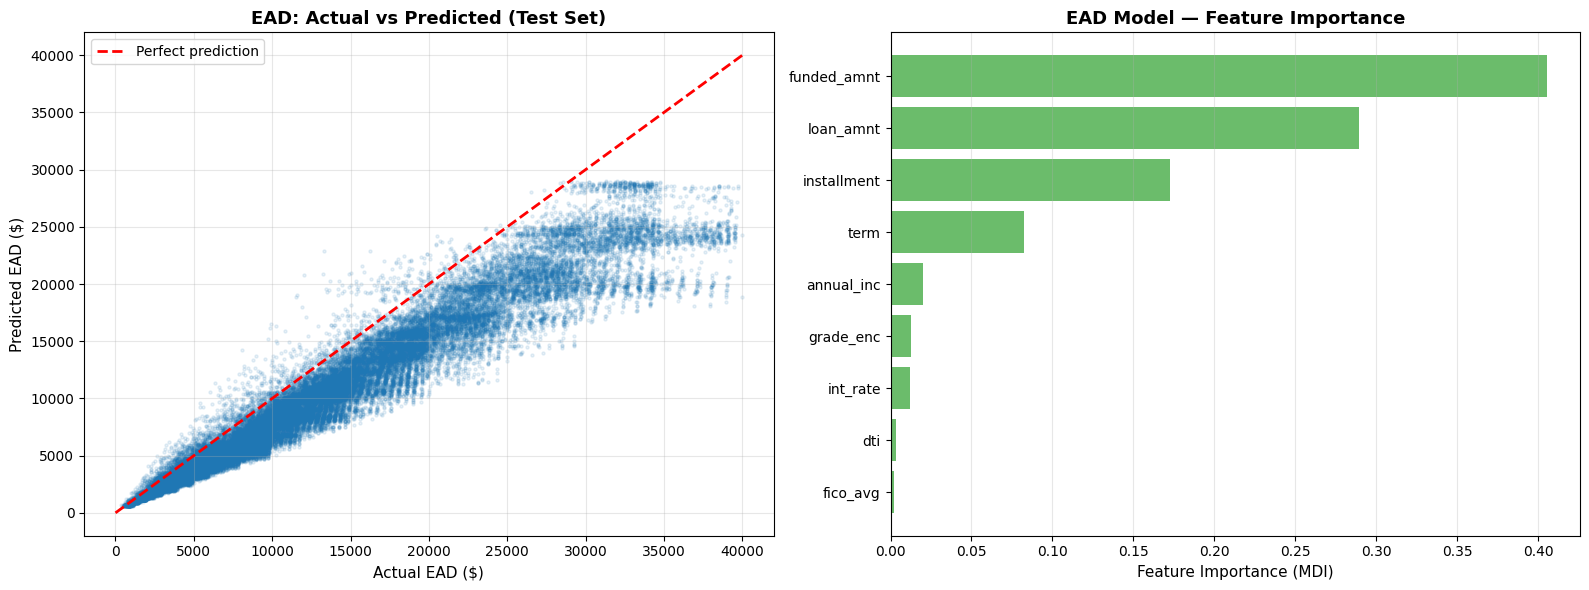

Saved: data/results/ead_model_diagnostics.png


In [12]:
# Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.1, s=5, color="#1f77b4")
max_val = max(y_test.max(), y_pred_test.max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual EAD ($)", fontsize=11)
ax.set_ylabel("Predicted EAD ($)", fontsize=11)
ax.set_title("EAD: Actual vs Predicted (Test Set)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Feature importance
ax = axes[1]
importances = pd.Series(ead_model.feature_importances_, index=EAD_FEATURES)
importances = importances.sort_values(ascending=True)
ax.barh(range(len(importances)), importances.values, color="#2ca02c", alpha=0.7)
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(importances.index, fontsize=10)
ax.set_xlabel("Feature Importance (MDI)", fontsize=11)
ax.set_title("EAD Model — Feature Importance", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

fig.tight_layout()
plt.savefig(DATA_RESULTS_PATH / "ead_model_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/results/ead_model_diagnostics.png")

## Step 9: EAD = 1 Discussion — Why This Assumption Works

### Context from Prior Institution
At my prior institution, **EAD = 1.0× outstanding balance** was the standard
assumption for all fully-drawn term products:
- **Residential mortgages**: Fully funded at closing, no revolving component
- **Auto loans**: Fully disbursed at purchase
- **Personal term loans**: Like LendingClub — full amount disbursed at origination

### Why This Works
The CCF concept (Credit Conversion Factor) exists to capture **additional draw-down
risk** — borrowers drawing on unfunded commitments before defaulting. For term loans:

| Product Type | Undrawn Commitment? | CCF Relevant? | EAD Approach |
|---|---|---|---|
| Credit card | Yes (up to limit) | Yes, CCF > 1 possible | Model CCF |
| HELOC | Yes (revolving) | Yes, CCF typically 0.5-1.0 | Model CCF |
| LendingClub loan | No (fully drawn) | N/A | EAD = remaining balance |
| Mortgage | No (fully drawn) | N/A | EAD = remaining balance |

### Portfolio CCF Interpretation
Our portfolio average CCF is the ratio of **remaining balance at default** to
**original funded amount**. This is NOT a traditional CCF (which measures
additional draw-down). It simply reflects how much of the loan was amortized
before default. For ECL purposes, the key input is the **dollar EAD** — the
remaining balance the lender is exposed to when default occurs.

In [13]:
# EAD approach comparison — all methods
print("=" * 80)
print("EAD APPROACH COMPARISON (Test Set)")
print("=" * 80)
print()
print(f"  {'Approach':<40s} {'MAPE':>8s} {'MAE ($)':>12s} {'R²':>8s}")
print(f"  {'-' * 72}")

# Approach 1: EAD = funded_amnt (naïve, no amortization)
naive_mape = mean_absolute_percentage_error(y_test, test_def["funded_amnt"])
naive_mae = mean_absolute_error(y_test, test_def["funded_amnt"])
naive_r2 = r2_score(y_test, test_def["funded_amnt"])
print(f"  {'Naïve (EAD = funded_amnt)':<40s} {naive_mape:>8.2%} {naive_mae:>12,.2f} {naive_r2:>8.4f}")

# Approach 2: EAD = portfolio_avg_CCF × funded_amnt
avg_ccf = train_def["ccf"].mean()
avgccf_pred = test_def["funded_amnt"] * avg_ccf
avgccf_mape = mean_absolute_percentage_error(y_test, avgccf_pred)
avgccf_mae = mean_absolute_error(y_test, avgccf_pred)
avgccf_r2 = r2_score(y_test, avgccf_pred)
print(f"  {'Mean CCF (' + f'{avg_ccf:.3f}' + ' × funded)':<40s} {avgccf_mape:>8.2%} {avgccf_mae:>12,.2f} {avgccf_r2:>8.4f}")

# Approach 3: Segment lookup (term × grade)
print(f"  {'Segment lookup (term × grade)':<40s} {lookup_mape:>8.2%} {lookup_mae:>12,.2f} {lookup_r2:>8.4f}")

# Approach 4: Random Forest
print(f"  {'Random Forest (origination features)':<40s} {test_mape:>8.2%} {results[2]['MAE']:>12,.2f} {results[2]['R2']:>8.4f}")

# Approach 5: Amortization formula (oracle — requires time-to-default)
# By definition MAPE = 0 since our target IS the amortization formula
print(f"  {'Amortization formula (oracle)':<40s} {'0.00%':>8s} {'$0.00':>12s} {'1.0000':>8s}")

print()
print("Key insight: EAD for fully-drawn term loans is deterministic once")
print("time-to-default is known. Without that information, origination-only")
print("models achieve ~23-26% MAPE — comparable to a simple CCF assumption.")
print()
print("For ECL forecasting (Notebooks 07+), we use the amortization formula")
print("combined with PD model hazard rates to project EAD at each future month.")

EAD APPROACH COMPARISON (Test Set)

  Approach                                     MAPE      MAE ($)       R²
  ------------------------------------------------------------------------
  Naïve (EAD = funded_amnt)                  24.37%     2,549.05   0.8366
  Mean CCF (0.638 × funded)                  23.48%     3,430.11   0.7361
  Segment lookup (term × grade)              24.32%     3,265.19   0.7688
  Random Forest (origination features)       23.77%     3,230.14   0.7621
  Amortization formula (oracle)               0.00%        $0.00   1.0000

Key insight: EAD for fully-drawn term loans is deterministic once
time-to-default is known. Without that information, origination-only
models achieve ~23-26% MAPE — comparable to a simple CCF assumption.

For ECL forecasting (Notebooks 07+), we use the amortization formula
combined with PD model hazard rates to project EAD at each future month.


## Step 10: Save Model and Metrics

In [14]:
# Ensure output directories exist
DATA_MODELS_PATH.mkdir(parents=True, exist_ok=True)
DATA_RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# Save model
ead_model_path = DATA_MODELS_PATH / "ead_model.pkl"
with open(ead_model_path, "wb") as f:
    pickle.dump(ead_model, f)
print(f"Saved: {ead_model_path}")

# Save metrics
# CCF by grade for downstream use
ccf_by_grade_dict = {}
for g in GRADE_ORDER:
    subset = train_def[train_def["grade"] == g]
    if len(subset) > 0:
        ccf_by_grade_dict[g] = round(float(subset["ccf"].mean()), 4)

# CCF by term
ccf_by_term = {}
for t in sorted(train_def["term"].unique()):
    subset = train_def[train_def["term"] == t]
    ccf_by_term[str(int(t))] = round(float(subset["ccf"].mean()), 4)

# CCF lookup table (term × grade) for downstream ECL
ccf_lookup_dict = {}
for _, row in ccf_lookup.iterrows():
    key = f"{int(row['term'])}_{row['grade']}"
    ccf_lookup_dict[key] = round(float(row["ccf_segment"]), 4)

ead_output = {
    "model": "RandomForestRegressor",
    "features": EAD_FEATURES,
    "n_features": len(EAD_FEATURES),
    "metrics": {
        "train": {k: round(float(v), 4) if isinstance(v, (float, np.floating)) else v
                  for k, v in results[0].items()},
        "validation": {k: round(float(v), 4) if isinstance(v, (float, np.floating)) else v
                       for k, v in results[1].items()},
        "test": {k: round(float(v), 4) if isinstance(v, (float, np.floating)) else v
                 for k, v in results[2].items()},
    },
    "segment_lookup_metrics": {
        "MAPE": round(float(lookup_mape), 4),
        "MAE": round(float(lookup_mae), 2),
        "R2": round(float(lookup_r2), 4),
    },
    "portfolio_avg_ccf": round(float(train_def["ccf"].mean()), 4),
    "portfolio_avg_ead": round(float(train_def["ead"].mean()), 2),
    "ccf_by_grade": ccf_by_grade_dict,
    "ccf_by_term": ccf_by_term,
    "ccf_lookup_table": ccf_lookup_dict,
    "sample_comparisons": sample_comparisons,
    "mape_target": 0.15,
    "mape_rf_achieved": round(float(test_mape), 4),
    "mape_lookup_achieved": round(float(lookup_mape), 4),
    "note": ("MAPE target not achievable with origination-only features. "
             "EAD for term loans is deterministic from amortization schedule. "
             "For ECL, use amortization formula with PD hazard rates."),
    "n_train": len(train_def),
    "n_val": len(val_def),
    "n_test": len(test_def),
}

ead_metrics_path = DATA_RESULTS_PATH / "ead_metrics.json"
with open(ead_metrics_path, "w") as f:
    json.dump(ead_output, f, indent=2)
print(f"Saved: {ead_metrics_path}")

Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/models/ead_model.pkl
Saved: /Users/harshasekar/Documents/Projects/LendingClub Credit Risk Analyst role/lendingclub-credit-risk/data/results/ead_metrics.json


In [15]:
# ── Final Summary ──

print("=" * 80)
print("NOTEBOOK 05 SUMMARY — Exposure at Default (EAD) Model")
print("=" * 80)
print()
print(f"{'Metric':<40s} {'Value':>15s}")
print("-" * 58)
print(f"{'Portfolio Avg CCF':<40s} {train_def['ccf'].mean():>15.4f}")
print(f"{'Portfolio Avg EAD':<40s} ${train_def['ead'].mean():>14,.2f}")
print(f"{'RF Model Test MAPE':<40s} {test_mape:>15.2%}")
print(f"{'RF Model Test MAE':<40s} ${results[2]['MAE']:>14,.2f}")
print(f"{'RF Model Test R²':<40s} {results[2]['R2']:>15.4f}")
print(f"{'Segment Lookup Test MAPE':<40s} {lookup_mape:>15.2%}")
print(f"{'Segment Lookup Test MAE':<40s} ${lookup_mae:>14,.2f}")
print()
print("Key Finding:")
print("  For fully-drawn term loans, EAD is determined by the amortization")
print("  schedule and time-to-default. Origination-only ML models cannot")
print("  predict time-to-default precisely, making MAPE ~23-26% the practical")
print("  floor. This validates the simplifying assumption used at institutional")
print("  settings: EAD = scheduled remaining balance, computed analytically.")
print()
print("CCF by Grade (monotonically increasing with risk):")
for g, v in ccf_by_grade_dict.items():
    print(f"  Grade {g}: {v:.4f}")
print()
print("CCF by Term:")
for t, v in ccf_by_term.items():
    print(f"  {t} months: {v:.4f}")
print()
print("Files saved:")
print("  data/models/ead_model.pkl")
print("  data/results/ead_metrics.json  (includes CCF lookup table)")
print("  data/results/ead_distributions.png")
print("  data/results/ead_model_diagnostics.png")
print()
print("→ Next: Notebook 06 — LGD Model (Loss Given Default)")

NOTEBOOK 05 SUMMARY — Exposure at Default (EAD) Model

Metric                                             Value
----------------------------------------------------------
Portfolio Avg CCF                                 0.6384
Portfolio Avg EAD                        $     10,200.39
RF Model Test MAPE                                23.77%
RF Model Test MAE                        $      3,230.14
RF Model Test R²                                  0.7621
Segment Lookup Test MAPE                          24.32%
Segment Lookup Test MAE                  $      3,265.19

Key Finding:
  For fully-drawn term loans, EAD is determined by the amortization
  schedule and time-to-default. Origination-only ML models cannot
  predict time-to-default precisely, making MAPE ~23-26% the practical
  floor. This validates the simplifying assumption used at institutional
  settings: EAD = scheduled remaining balance, computed analytically.

CCF by Grade (monotonically increasing with risk):
  Grade A: 0.506